<a href="https://colab.research.google.com/github/VasilisPapageorgiou/Amortization-of-Risk-Indicators/blob/main/Amortization_Exp5_3_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

1 = RESUME latest run
2 = START NEW run
Choose 1 or 2: 1
ROOT: /content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214
Signature: 6730eb0a69d7dd2c
CPU=2 | exact workers=2 | Numba=2 | Torch=2
TRAIN: full cache (2,000)
VALIDATION: full cache (380)
TEST_SEEN: full cache (380)
TEST_INTERP: full cache (360)

Train=2000 | Val=380 | Seen=380 | Interp=360

REPLICATION 1/5
MC rep 1: final cache
rep01_m1: complete — skipping
rep01_m5: complete — skipping
rep01_m10: complete — skipping
rep01_m25: complete — skipping

REPLICATION 2/5
MC rep 2: final cache
rep02_m1: complete — skipping
rep02_m5: complete — skipping
rep02_m10: complete — skipping
rep02_m25: complete — skipping

REPLICATION 3/5
MC rep 3: final cache
rep03_m1: complete — skipping
rep03_m5: complete — skipping
rep03_m10: complete — skipping
rep03_m25: complete — skipping

REPLICATION 4/5
MC rep 4: final cache
rep04_m1: complete — skipping
rep04_m5: complete — skipping
rep04_m10: co

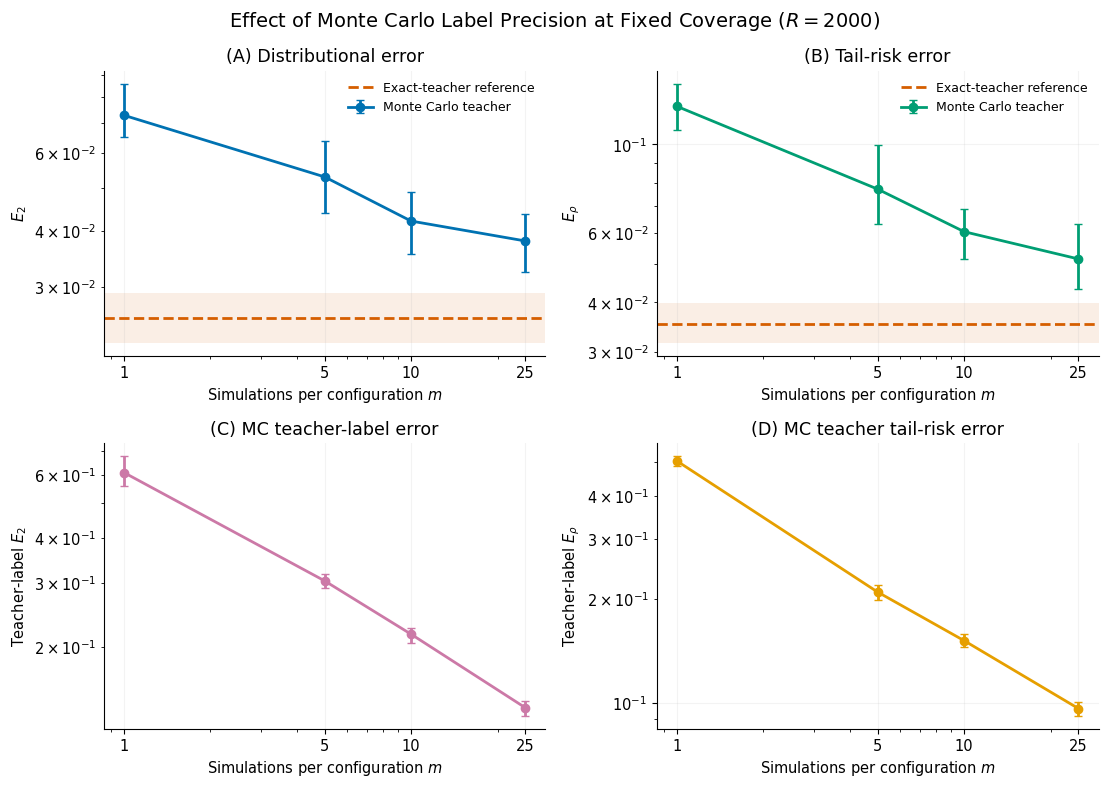


5.3-A COMPLETE
R: 2000
m: (1, 5, 10, 25)
Replications: 5
Nested MC trajectories/replication: 50,000
Total nested MC trajectories: 250,000

Main table:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/main_table_5_3A.tex

Main figure:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/figure_5_3A_main.pdf

Diagnostics:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/full_numeric_summary.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/raw_test_errors.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/teacher_label_errors.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/exact_reference_contrast.csv
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/results/robustness_by_stratum.csv
/content/d

In [2]:
# =====================================================================================
# EXPERIMENT 5.3-A — EXACT vs MONTE CARLO TEACHING AT FIXED R
# FINAL / JASA-LEVEL / RESUMABLE / CPU-ONLY
#
# R = 2000
# m = 1, 5, 10, 25
# 5 independent MC/training replications
#
# Within replication:
#   - same 2000 configurations
#   - same 25 nested MC paths/configuration
#   - same neural initialization / batch randomization across teachers
#
# Main outputs:
#   main_table_5_3A.tex
#   figure_5_3A_main.pdf
#
# Additional:
#   raw_test_errors.csv
#   teacher_label_errors.csv
#   exact_reference_contrast.csv
#   robustness_by_stratum.csv
#   training_diagnostics.csv
#
# CPU ONLY | SPARSE LU | NO MATRIX INVERSE
# =====================================================================================


# =====================================================================================
# 0. DRIVE + IMPORTS
# =====================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import json, hashlib, math, pickle, random, time
from dataclasses import dataclass, asdict
from datetime import datetime
from functools import lru_cache
from pathlib import Path
from typing import Tuple

import numpy as np
import pandas as pd

from scipy import sparse
from scipy.sparse.linalg import splu
from scipy.stats import qmc
from joblib import Parallel, delayed

from numba import njit, prange, set_num_threads, get_num_threads

import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# =====================================================================================
# 1. CONFIG
# =====================================================================================

@dataclass
class Config:
    seed:int = 20260820

    beta:Tuple[float,float] = (.30,1.50)
    gamma:Tuple[float,float] = (.20,1.00)
    omega:Tuple[float,float] = (.02,.50)
    frac:Tuple[float,float] = (.02,.20)

    trainN:Tuple[int,...] = tuple(range(40,401,20))

    R:int = 2000

    width:int = 128
    depth:int = 3
    batch:int = 64
    epochs:int = 500

    lr:float = 1e-3
    wd:float = 1e-6
    patience:int = 20
    min_delta:float = 1e-6
    clip:float = 5.

    prob_tol:float = 1e-10
    refine_steps:int = 3


cfg = Config()

M_VALUES = (1,5,10,25)
N_REP = 5

VAL_PER_N = 20
TEST_PER_N = 20

SEEN_N = cfg.trainN
INTERP_N = tuple(range(50,400,20))

N_VAL = len(SEEN_N)*VAL_PER_N
N_TEST_SEEN = len(SEEN_N)*TEST_PER_N
N_TEST_INTERP = len(INTERP_N)*TEST_PER_N

N_SCALE = max(cfg.trainN)

MC_LEVELS = np.asarray(M_VALUES,dtype=np.int64)
MAX_M = max(M_VALUES)

MC_PER_REP = cfg.R*MAX_M
assert MC_PER_REP == 50_000
assert set(SEEN_N).isdisjoint(INTERP_N)

EXACT_CHUNK = 50
MC_CHUNK = 100
CHECKPOINT_EVERY = 5
BOOT_B = 3000


# =====================================================================================
# 2. RUN PROTECTION
# =====================================================================================

CODE_VERSION = "5.3A_JASA_v1"

SCIENTIFIC_CONFIG = {
    "code_version":CODE_VERSION,
    "config":asdict(cfg),
    "M_VALUES":M_VALUES,
    "N_REP":N_REP,
    "VAL_PER_N":VAL_PER_N,
    "TEST_PER_N":TEST_PER_N,
    "SEEN_N":SEEN_N,
    "INTERP_N":INTERP_N,
    "protocol":"nested MC paths; common initialization within replication"
}

def make_signature(x):
    s=json.dumps(x,sort_keys=True,default=str)
    return hashlib.sha256(s.encode()).hexdigest()[:16]

SIG=make_signature(SCIENTIFIC_CONFIG)

BASE=Path(
    "/content/drive/MyDrive/StatisticalLearning/"
    "Experiment_5_3A_JASA"
)
BASE.mkdir(parents=True,exist_ok=True)

print("\n"+"="*80)
print("1 = RESUME latest run")
print("2 = START NEW run")
print("="*80)

mode=input("Choose 1 or 2: ").strip()
if mode not in ("1","2"):
    raise RuntimeError("Choose 1 or 2.")

latest=BASE/"latest_run.txt"

if mode=="2":
    stamp=datetime.now().strftime("%Y%m%d_%H%M%S")
    ROOT=BASE/f"run_{stamp}"
    ROOT.mkdir()

    with open(ROOT/"manifest.pkl","wb") as f:
        pickle.dump(
            {"signature":SIG,"scientific_config":SCIENTIFIC_CONFIG},
            f,pickle.HIGHEST_PROTOCOL
        )

    latest.write_text(ROOT.name)

else:
    if not latest.exists():
        raise RuntimeError("No previous run. Choose START NEW.")

    ROOT=BASE/latest.read_text().strip()

    with open(ROOT/"manifest.pkl","rb") as f:
        old=pickle.load(f)

    if old["signature"] != SIG:
        raise RuntimeError(
            "Scientific specification changed. "
            "RESUME aborted; choose START NEW."
        )


CACHE=ROOT/"cache"
EXACT=CACHE/"exact"
MC=CACHE/"mc"
MODELS=CACHE/"models"
CKPT=CACHE/"checkpoints"
OUT=ROOT/"results"

for d in (CACHE,EXACT,MC,MODELS,CKPT,OUT):
    d.mkdir(parents=True,exist_ok=True)

print("ROOT:",ROOT)
print("Signature:",SIG)


# =====================================================================================
# 3. UTILITIES / CPU
# =====================================================================================

def atomic_pickle(x,path):
    path=Path(path)
    tmp=path.with_suffix(path.suffix+".tmp")
    with open(tmp,"wb") as f:
        pickle.dump(x,f,pickle.HIGHEST_PROTOCOL)
    os.replace(tmp,path)

def atomic_torch(x,path):
    path=Path(path)
    tmp=path.with_suffix(path.suffix+".tmp")
    torch.save(x,tmp)
    os.replace(tmp,path)

def load_pickle(path,default=None):
    try:
        with open(path,"rb") as f:
            return pickle.load(f)
    except Exception:
        return default

def seed_all(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)

seed_all(cfg.seed)

CPU=os.cpu_count() or 1
N_EXACT=max(1,min(2,CPU))
N_MC=max(1,min(CPU,get_num_threads()))

set_num_threads(N_MC)
torch.set_num_threads(max(1,min(8,CPU)))

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

try:
    torch.use_deterministic_algorithms(True,warn_only=True)
except Exception:
    pass

print(
    f"CPU={CPU} | exact workers={N_EXACT} | "
    f"Numba={N_MC} | Torch={torch.get_num_threads()}"
)


# =====================================================================================
# 4. EXACT MARKOVIAN TEACHER
# =====================================================================================

@dataclass
class Rec:
    b:float
    g:float
    w:float
    N:int
    i0:int
    p:np.ndarray


@lru_cache(None)
def topo(N):
    states=[
        (s,i)
        for i in range(1,N+1)
        for s in range(N-i+1)
    ]

    ix={x:j for j,x in enumerate(states)}
    M=len(states)

    ir=[]; ic=[]; ib=[]
    rr=[]; rc=[]; rb=[]
    wr=[]; wc=[]; wb=[]

    db=np.zeros(M)
    dg=np.zeros(M)
    dw=np.zeros(M)
    qb=np.zeros(M)

    for j,(s,i) in enumerate(states):
        r=N-s-i

        if s:
            ir.append(j)
            ic.append(ix[(s-1,i+1)])
            rate=s*i/N
            ib.append(rate)
            db[j]=rate

        dg[j]=i

        if i==1:
            qb[j]=i
        else:
            rr.append(j)
            rc.append(ix[(s,i-1)])
            rb.append(i)

        if r:
            wr.append(j)
            wc.append(ix[(s+1,i)])
            wb.append(r)
            dw[j]=r

    A=lambda x,d=float:np.asarray(x,dtype=d)

    return (
        ix,M,
        A(ir,int),A(ic,int),A(ib),
        A(rr,int),A(rc,int),A(rb),
        A(wr,int),A(wc,int),A(wb),
        db,dg,dw,qb
    )


def refined(A,lu,b,transpose=False):
    b=np.asarray(b,dtype=np.float64)
    mode="T" if transpose else "N"

    x=lu.solve(b,trans=mode)

    for _ in range(cfg.refine_steps):
        r=b-(A.T@x if transpose else A@x)

        if not np.all(np.isfinite(r)):
            break

        rel=np.linalg.norm(r,np.inf)/max(np.linalg.norm(b,np.inf),1.)

        if rel<1e-11:
            break

        x+=lu.solve(r,trans=mode)

    return np.asarray(x,dtype=np.float64)


def exact_p(b,g,w,N,i0):
    (
        ix,M,ir,ic,ib,rr,rc,rb,
        wr,wc,wb,db,dg,dw,qb
    )=topo(N)

    rows=np.r_[ir,rr,wr,np.arange(M)]
    cols=np.r_[ic,rc,wc,np.arange(M)]

    vals=np.r_[
        b*ib,
        g*rb,
        w*wb,
        -(b*db+g*dg+w*dw)
    ]

    T=sparse.coo_matrix(
        (vals,(rows,cols)),
        shape=(M,M),
        dtype=np.float64
    ).tocsc()

    D1=sparse.coo_matrix(
        (b*ib,(ir,ic)),
        shape=(M,M),
        dtype=np.float64
    ).tocsc()

    D0=(T-D1).tocsc()
    A0=(-D0).tocsc()

    lu=splu(A0,permc_spec="COLAMD")

    q=g*qb

    v=np.zeros(M)
    v[ix[(N-i0,i0)]]=1.

    bvec=refined(A0,lu,q)
    D1T=D1.T.tocsr()

    p=np.zeros(N+2)

    for k in range(N+1):
        p[k]=v@bvec

        y=refined(
            A0,lu,v,
            transpose=True
        )

        v=np.asarray(
            D1T@y
        ).ravel()

    p[-1]=v.sum()
    p[np.abs(p)<cfg.prob_tol]=0.

    if (
        not np.all(np.isfinite(p))
        or p.min() < -cfg.prob_tol
    ):
        raise RuntimeError("Invalid exact PMF.")

    p=np.maximum(p,0.)
    mass=p.sum()

    if not np.isfinite(mass) or abs(mass-1.)>1e-5:
        raise RuntimeError(f"Invalid probability mass={mass}.")

    return p/mass


# =====================================================================================
# 5. DESIGN + RESUMABLE EXACT DATA
# =====================================================================================

def design(n,Ns,seed):
    U=qmc.LatinHypercube(
        d=4,seed=seed
    ).random(n)

    scale=lambda x,a:a[0]+(a[1]-a[0])*x

    b=scale(U[:,0],cfg.beta)
    g=scale(U[:,1],cfg.gamma)
    w=scale(U[:,2],cfg.omega)
    f=scale(U[:,3],cfg.frac)

    Nv=np.tile(
        np.asarray(Ns),
        math.ceil(n/len(Ns))
    )[:n]

    rng=np.random.default_rng(seed+991)
    rng.shuffle(Nv)

    i0=np.asarray([
        int(np.clip(
            round(f[j]*Nv[j]),
            2,Nv[j]
        ))
        for j in range(n)
    ])

    for N in Ns:
        z=np.where(Nv==N)[0]

        if len(z):
            k=max(1,round(.25*len(z)))
            i0[
                rng.choice(z,k,replace=False)
            ]=1

    return [
        (
            float(b[j]),
            float(g[j]),
            float(w[j]),
            int(Nv[j]),
            int(i0[j])
        )
        for j in range(n)
    ]


def records_match(records,configs,tol=1e-12):
    if records is None or len(records)!=len(configs):
        return False

    for r,x in zip(records,configs):
        b,g,w,N,i0=x

        if (
            abs(r.b-b)>tol or
            abs(r.g-g)>tol or
            abs(r.w-w)>tol or
            r.N!=N or
            r.i0!=i0
        ):
            return False

    return True


def exact_one(j,x):
    return j,Rec(*x,exact_p(*x))


def exact_set(configs,name):
    full=EXACT/f"{name}_full.pkl"

    if full.exists():
        z=load_pickle(full)

        if records_match(z,configs):
            print(f"{name}: full cache ({len(z):,})")
            return z

    folder=EXACT/name
    folder.mkdir(parents=True,exist_ok=True)

    ans=[]

    for start in range(0,len(configs),EXACT_CHUNK):
        end=min(start+EXACT_CHUNK,len(configs))
        cc=configs[start:end]

        f=folder/f"chunk_{start:05d}_{end:05d}.pkl"
        part=load_pickle(f) if f.exists() else None

        if not records_match(part,cc):
            jobs=list(enumerate(cc))
            jobs.sort(
                key=lambda z:z[1][3],
                reverse=True
            )

            t0=time.perf_counter()

            out=Parallel(
                n_jobs=N_EXACT,
                backend="threading"
            )(
                delayed(exact_one)(j,x)
                for j,x in jobs
            )

            out.sort(key=lambda z:z[0])
            part=[r for _,r in out]

            atomic_pickle(part,f)

            print(
                f"{name} {start:5d}:{end:5d} | "
                f"{time.perf_counter()-t0:.1f}s | saved"
            )
        else:
            print(
                f"{name} {start:5d}:{end:5d} | cache"
            )

        ans.extend(part)

    if not records_match(ans,configs):
        raise RuntimeError(f"{name}: design/cache mismatch.")

    atomic_pickle(ans,full)
    return ans


# =====================================================================================
# 6. FIXED TRAIN / VALIDATION / TEST DESIGNS
# =====================================================================================

train_design=design(
    cfg.R,
    cfg.trainN,
    cfg.seed+1
)

val_design=design(
    N_VAL,
    cfg.trainN,
    cfg.seed+2
)

seen_design=design(
    N_TEST_SEEN,
    SEEN_N,
    cfg.seed+3
)

interp_design=design(
    N_TEST_INTERP,
    INTERP_N,
    cfg.seed+4
)

train=exact_set(train_design,"TRAIN")
val=exact_set(val_design,"VALIDATION")
test_seen=exact_set(seen_design,"TEST_SEEN")
test_interp=exact_set(interp_design,"TEST_INTERP")

test=test_seen+test_interp

test_split=np.asarray(
    ["seen"]*len(test_seen)
    +
    ["interpolation"]*len(test_interp)
)

print(
    f"\nTrain={len(train)} | Val={len(val)} | "
    f"Seen={len(test_seen)} | Interp={len(test_interp)}"
)


# =====================================================================================
# 7. NESTED MONTE CARLO
# =====================================================================================

@njit
def sim_C(b,g,w,N,i0):
    S=N-i0
    I=i0
    R=0
    C=0

    while I>0:
        inf=b*S*I/N
        rec=g*I
        wan=w*R

        z=np.random.random()*(inf+rec+wan)

        if z<inf:
            S-=1
            I+=1
            C+=1

            # exact for truncated-with-overflow count target
            if C>=N+1:
                return N+1

        elif z<inf+rec:
            I-=1
            R+=1

        else:
            R-=1
            S+=1

    return C


@njit(parallel=True)
def mc_chunk(
    B,G,W,N,I0,
    global_start,
    maxN,
    seed
):
    n=len(N)
    out=np.zeros(
        (4,n,maxN+2),
        dtype=np.int16
    )

    levels=np.asarray(
        [1,5,10,25],
        dtype=np.int64
    )

    for j in prange(n):
        gj=global_start+j

        np.random.seed(
            seed+100003*gj
        )

        hist=np.zeros(
            maxN+2,
            dtype=np.int16
        )

        level=0

        for q in range(1,26):
            c=sim_C(
                B[j],G[j],W[j],
                N[j],I0[j]
            )

            hist[c]+=1

            if (
                level<4
                and q==levels[level]
            ):
                out[level,j,:]=hist
                level+=1

    return out


LEVEL={1:0,5:1,10:2,25:3}


def mc_labels(rep):
    folder=MC/f"rep_{rep:02d}"
    folder.mkdir(parents=True,exist_ok=True)

    final=folder/"labels_final.pkl"

    if final.exists():
        z=load_pickle(final)

        if (
            z is not None
            and all(m in z for m in M_VALUES)
        ):
            print(f"MC rep {rep}: final cache")
            return z

    B=np.asarray([r.b for r in train])
    G=np.asarray([r.g for r in train])
    W=np.asarray([r.w for r in train])

    N=np.asarray(
        [r.N for r in train],
        dtype=np.int64
    )

    I0=np.asarray(
        [r.i0 for r in train],
        dtype=np.int64
    )

    seed=(
        cfg.seed
        +900000
        +rep*1000003
    )

    # compile
    _=mc_chunk(
        np.asarray([.8]),
        np.asarray([.5]),
        np.asarray([.1]),
        np.asarray([40],dtype=np.int64),
        np.asarray([1],dtype=np.int64),
        0,40,seed
    )

    pieces=[]

    for start in range(0,cfg.R,MC_CHUNK):
        end=min(start+MC_CHUNK,cfg.R)

        f=folder/f"chunk_{start:05d}_{end:05d}.pkl"
        part=load_pickle(f) if f.exists() else None

        if (
            part is None
            or part.shape!=(4,end-start,N_SCALE+2)
        ):
            t0=time.perf_counter()

            part=mc_chunk(
                B[start:end],
                G[start:end],
                W[start:end],
                N[start:end],
                I0[start:end],
                start,
                N_SCALE,
                seed
            )

            atomic_pickle(part,f)

            print(
                f"MC rep={rep} "
                f"{start:4d}:{end:4d} | "
                f"{time.perf_counter()-t0:.1f}s"
            )
        else:
            print(
                f"MC rep={rep} "
                f"{start:4d}:{end:4d} | cache"
            )

        pieces.append(part)

    raw=np.concatenate(pieces,axis=1)

    labels={}

    for m in M_VALUES:
        q=LEVEL[m]

        labels[m]=[
            raw[q,j,:train[j].N+2].astype(np.float32)/m
            for j in range(cfg.R)
        ]

    atomic_pickle(labels,final)

    del raw,pieces

    return labels


# =====================================================================================
# 8. NETWORK / PACK / LOSS
# =====================================================================================

class HazardNet(nn.Module):
    def __init__(self):
        super().__init__()

        L=[]
        d=6

        for _ in range(cfg.depth):
            L += [
                nn.Linear(d,cfg.width),
                nn.SiLU()
            ]
            d=cfg.width

        L.append(nn.Linear(d,1))
        self.net=nn.Sequential(*L)

    def forward(self,x):
        return torch.sigmoid(
            self.net(x).squeeze(-1)
        )


def pack(records,labels=None):
    groups={}

    for j,r in enumerate(records):
        groups.setdefault(r.N,[]).append(j)

    P={}

    for N,idx in groups.items():
        idx=np.asarray(idx,dtype=int)

        B=len(idx)
        K=N+1

        b=torch.tensor(
            [records[j].b for j in idx],
            dtype=torch.float32
        )[:,None]

        g=torch.tensor(
            [records[j].g for j in idx],
            dtype=torch.float32
        )[:,None]

        w=torch.tensor(
            [records[j].w for j in idx],
            dtype=torch.float32
        )[:,None]

        ns=torch.full(
            (B,1),
            N/N_SCALE,
            dtype=torch.float32
        )

        i0=torch.tensor(
            [records[j].i0/N for j in idx],
            dtype=torch.float32
        )[:,None]

        c=(
            torch.arange(K,dtype=torch.float32)/N
        )[None,:]

        X=torch.stack([
            b.expand(B,K),
            g.expand(B,K),
            w.expand(B,K),
            ns.expand(B,K),
            i0.expand(B,K),
            c.expand(B,K)
        ],dim=2).contiguous()

        Y=np.stack([
            records[j].p
            if labels is None
            else labels[j]
            for j in idx
        ]).astype(np.float32)

        P[N]={
            "X":X,
            "Y":torch.from_numpy(Y),
            "orig":idx,
            "n":B
        }

    return P


def pmf_from_h(h):
    B=h.shape[0]

    before=torch.cat([
        torch.ones(
            (B,1),
            dtype=h.dtype
        ),
        torch.cumprod(
            1-h[:,:-1],
            dim=1
        )
    ],dim=1)

    return torch.cat([
        before*h,
        torch.prod(
            1-h,
            dim=1,
            keepdim=True
        )
    ],dim=1)


def tail(P):
    return torch.flip(
        torch.cumsum(
            torch.flip(
                P[:,1:],
                dims=[1]
            ),
            dim=1
        ),
        dims=[1]
    )


def predict_batch(net,X):
    B,K,_=X.shape

    h=net(
        X.reshape(B*K,6)
    ).reshape(B,K)

    return pmf_from_h(h)


def loss_batch(net,X,Y):
    P=predict_batch(net,X)

    lp=torch.sum(
        (P-Y)**2,
        dim=1
    )

    lr=torch.mean(
        (tail(P)-tail(Y))**2,
        dim=1
    )

    return (lp+lr).mean()


def batches(P,rng,shuffle=True):
    jobs=[]

    for N,G in P.items():
        idx=np.arange(G["n"])

        if shuffle:
            rng.shuffle(idx)

        for s in range(0,len(idx),cfg.batch):
            jobs.append(
                (N,idx[s:s+cfg.batch])
            )

    if shuffle:
        rng.shuffle(jobs)

    return jobs


@torch.no_grad()
def val_loss(net,P):
    net.eval()

    total=0.
    n=0

    for N,G in P.items():
        for s in range(0,G["n"],cfg.batch):
            X=G["X"][s:s+cfg.batch]
            Y=G["Y"][s:s+cfg.batch]

            L=loss_batch(net,X,Y)

            total+=L.item()*len(X)
            n+=len(X)

    return total/n


# =====================================================================================
# 9. RESUMABLE TRAINING
# =====================================================================================

def cpu_state(state):
    return {
        k:v.detach().cpu()
        for k,v in state.items()
    }


def fit(TR,VA,name,seed):
    final=MODELS/f"{name}_FINAL.pt"
    checkpoint=CKPT/f"{name}_CHECKPOINT.pt"

    if final.exists():
        z=torch.load(
            final,
            map_location="cpu",
            weights_only=False
        )

        net=HazardNet()
        net.load_state_dict(z["state"])

        print(
            f"{name}: final model | "
            f"best epoch={z['best_epoch']}"
        )

        return net,z

    seed_all(seed)

    net=HazardNet()

    opt=torch.optim.AdamW(
        net.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.wd
    )

    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=.5,
        patience=15
    )

    rng=np.random.default_rng(seed+8)

    start_epoch=1
    best=np.inf
    best_epoch=0
    best_state=None
    wait=0
    history=[]
    previous_elapsed=0.

    if checkpoint.exists():
        z=torch.load(
            checkpoint,
            map_location="cpu",
            weights_only=False
        )

        net.load_state_dict(z["model"])
        opt.load_state_dict(z["optimizer"])
        sch.load_state_dict(z["scheduler"])

        start_epoch=z["epoch"]+1

        best=z["best"]
        best_epoch=z["best_epoch"]
        best_state=z["best_state"]
        wait=z["wait"]

        history=z["history"]
        previous_elapsed=z["elapsed"]

        rng.bit_generator.state=z["rng_state"]
        torch.set_rng_state(z["torch_rng"])

        print(
            f"{name}: resume epoch {start_epoch}"
        )

    start=time.perf_counter()
    stopped=cfg.epochs

    for epoch in range(start_epoch,cfg.epochs+1):
        net.train()

        for N,idx in batches(TR,rng,True):
            X=TR[N]["X"][idx]
            Y=TR[N]["Y"][idx]

            opt.zero_grad(set_to_none=True)

            L=loss_batch(net,X,Y)

            if not torch.isfinite(L):
                raise RuntimeError(f"{name}: non-finite loss.")

            L.backward()

            torch.nn.utils.clip_grad_norm_(
                net.parameters(),
                cfg.clip
            )

            opt.step()

        v=val_loss(net,VA)
        sch.step(v)

        history.append(float(v))

        if (
            best_state is None
            or v<best-cfg.min_delta
        ):
            best=float(v)
            best_epoch=epoch
            best_state=cpu_state(
                net.state_dict()
            )
            wait=0
        else:
            wait+=1

        if (
            epoch==1
            or epoch%CHECKPOINT_EVERY==0
        ):
            elapsed=(
                previous_elapsed
                +time.perf_counter()
                -start
            )

            atomic_torch({
                "epoch":epoch,
                "model":cpu_state(net.state_dict()),
                "optimizer":opt.state_dict(),
                "scheduler":sch.state_dict(),
                "best":best,
                "best_epoch":best_epoch,
                "best_state":best_state,
                "wait":wait,
                "history":history,
                "rng_state":rng.bit_generator.state,
                "torch_rng":torch.get_rng_state(),
                "elapsed":elapsed
            },checkpoint)

            print(
                f"{name} | ep={epoch:3d} | "
                f"val={v:.4e} | best={best:.4e} | "
                f"wait={wait}"
            )

        if wait>=cfg.patience:
            stopped=epoch
            break

    elapsed=(
        previous_elapsed
        +time.perf_counter()
        -start
    )

    if best_state is None:
        raise RuntimeError(f"{name}: no valid model.")

    net.load_state_dict(best_state)

    payload={
        "state":best_state,
        "best_epoch":best_epoch,
        "stopped_epoch":stopped,
        "validation":best,
        "training_sec":elapsed,
        "history":history
    }

    atomic_torch(payload,final)

    if checkpoint.exists():
        checkpoint.unlink()

    print(
        f"{name}: COMPLETE | "
        f"best={best_epoch} | stop={stopped}"
    )

    return net,payload


# =====================================================================================
# 10. TEST / LABEL METRICS
# =====================================================================================

@torch.no_grad()
def evaluate(net,P,n_total):
    net.eval()

    E2=np.full(n_total,np.nan)
    Erho=np.full(n_total,np.nan)
    KL=np.full(n_total,np.nan)

    for N,G in P.items():
        for s in range(0,G["n"],cfg.batch):
            e=min(s+cfg.batch,G["n"])

            loc=np.arange(s,e)
            orig=G["orig"][loc]

            X=G["X"][loc]
            Y=G["Y"][loc]

            Ph=predict_batch(net,X)

            E2[orig]=(
                torch.linalg.vector_norm(
                    Ph-Y,
                    dim=1
                ).numpy()
            )

            Erho[orig]=(
                torch.max(
                    torch.abs(
                        tail(Ph)-tail(Y)
                    ),
                    dim=1
                ).values.numpy()
            )

            Psafe=torch.clamp(
                Ph,
                min=1e-12,
                max=1.
            )

            terms=torch.where(
                Y>0,
                Y*torch.log(Y/Psafe),
                torch.zeros_like(Y)
            )

            KL[orig]=(
                terms.sum(dim=1).numpy()
            )

    return {
        "E2":E2,
        "Erho":Erho,
        "KL":KL
    }


def tail_np(p):
    return np.flip(
        np.cumsum(
            np.flip(p[1:])
        )
    )


def teacher_errors(records,labels):
    E2=[]
    Erho=[]

    for r,p in zip(records,labels):
        p=np.asarray(p)

        E2.append(
            np.linalg.norm(p-r.p)
        )

        Erho.append(
            np.max(
                np.abs(
                    tail_np(p)
                    -
                    tail_np(r.p)
                )
            )
        )

    return {
        "E2":np.asarray(E2),
        "Erho":np.asarray(Erho)
    }


# =====================================================================================
# 11. PACK FIXED EXACT DATA
# =====================================================================================

TR_EXACT=pack(train)
VA=pack(val)
TE=pack(test)


# =====================================================================================
# 12. EXPERIMENT
# =====================================================================================

PROGRESS_FILE=ROOT/"experiment_progress.pkl"

progress=load_pickle(
    PROGRESS_FILE,
    {
        "exact":{},
        "mc":{},
        "label":{}
    }
)

for key in ("exact","mc","label"):
    progress.setdefault(key,{})


for rep in range(1,N_REP+1):
    print("\n"+"="*95)
    print(f"REPLICATION {rep}/{N_REP}")
    print("="*95)

    # same optimization seed for exact and every m within replication
    train_seed=(
        cfg.seed
        +7001
        +rep*100003
    )

    # -------------------------------------------------------------------------
    # Exact-teacher reference
    # -------------------------------------------------------------------------

    ekey=f"rep{rep:02d}"

    if ekey not in progress["exact"]:
        net,meta=fit(
            TR_EXACT,
            VA,
            f"rep{rep:02d}_EXACT_R2000",
            train_seed
        )

        z=evaluate(
            net,
            TE,
            len(test)
        )

        progress["exact"][ekey]={
            **z,
            "training_sec":meta["training_sec"],
            "best_epoch":meta["best_epoch"],
            "stopped_epoch":meta["stopped_epoch"]
        }

        atomic_pickle(
            progress,
            PROGRESS_FILE
        )

        del net

    # -------------------------------------------------------------------------
    # Independent nested MC realization for this replication
    # -------------------------------------------------------------------------

    labels=mc_labels(rep)

    for m in M_VALUES:
        key=f"rep{rep:02d}_m{m}"

        # teacher-label error
        if key not in progress["label"]:
            progress["label"][key]=teacher_errors(
                train,
                labels[m]
            )

            atomic_pickle(
                progress,
                PROGRESS_FILE
            )

        # MC-trained model
        if key in progress["mc"]:
            print(f"{key}: complete — skipping")
            continue

        TR=pack(
            train,
            labels[m]
        )

        net,meta=fit(
            TR,
            VA,
            f"rep{rep:02d}_MC_R2000_m{m}",
            train_seed
        )

        z=evaluate(
            net,
            TE,
            len(test)
        )

        progress["mc"][key]={
            "m":m,
            **z,
            "training_sec":meta["training_sec"],
            "best_epoch":meta["best_epoch"],
            "stopped_epoch":meta["stopped_epoch"]
        }

        atomic_pickle(
            progress,
            PROGRESS_FILE
        )

        print(
            f"m={m:2d} | "
            f"E2={np.median(z['E2']):.5g} | "
            f"Erho={np.median(z['Erho']):.5g}"
        )

        del TR,net


# =====================================================================================
# 13. MATRICES + HIERARCHICAL BOOTSTRAP
# =====================================================================================

def exact_matrix(metric):
    return np.vstack([
        progress["exact"][
            f"rep{rep:02d}"
        ][metric]
        for rep in range(1,N_REP+1)
    ])


def mc_matrix(m,metric):
    return np.vstack([
        progress["mc"][
            f"rep{rep:02d}_m{m}"
        ][metric]
        for rep in range(1,N_REP+1)
    ])


def label_matrix(m,metric):
    return np.vstack([
        progress["label"][
            f"rep{rep:02d}_m{m}"
        ][metric]
        for rep in range(1,N_REP+1)
    ])


def hier_boot(A,B=BOOT_B,seed=1):
    A=np.asarray(A,float)
    nr,nc=A.shape

    rng=np.random.default_rng(seed)
    z=np.empty(B)

    for b in range(B):
        ir=rng.integers(
            0,nr,size=nr
        )

        ic=rng.integers(
            0,nc,size=nc
        )

        z[b]=np.median(
            A[ir][:,ic]
        )

    return (
        float(np.quantile(z,.025)),
        float(np.quantile(z,.975))
    )


def summarize(A,seed):
    x=np.asarray(A,float)

    lo,hi=hier_boot(
        x,
        seed=seed
    )

    return {
        "median":float(np.median(x)),
        "q1":float(np.quantile(x,.25)),
        "q3":float(np.quantile(x,.75)),
        "p95":float(np.quantile(x,.95)),
        "CI_low":lo,
        "CI_high":hi
    }


def paired_contrast(A,Bmat,seed):
    A=np.asarray(A,float)
    Bmat=np.asarray(Bmat,float)

    assert A.shape==Bmat.shape

    nr,nc=A.shape
    rng=np.random.default_rng(seed)

    z=np.empty(BOOT_B)

    for b in range(BOOT_B):
        ir=rng.integers(
            0,nr,size=nr
        )

        ic=rng.integers(
            0,nc,size=nc
        )

        As=A[ir][:,ic]
        Bs=Bmat[ir][:,ic]

        z[b]=(
            np.median(As)
            -
            np.median(Bs)
        )

    return {
        "estimate":float(
            np.median(A)-np.median(Bmat)
        ),
        "CI_low":float(np.quantile(z,.025)),
        "CI_high":float(np.quantile(z,.975))
    }


# =====================================================================================
# 14. MAIN NUMERICAL SUMMARY
# =====================================================================================

summary=[]

# exact reference
e2=summarize(
    exact_matrix("E2"),
    cfg.seed+101
)

er=summarize(
    exact_matrix("Erho"),
    cfg.seed+102
)

kl=summarize(
    exact_matrix("KL"),
    cfg.seed+103
)

summary.append({
    "Teacher":"Exact reference",
    "m":np.nan,

    "E2_med":e2["median"],
    "E2_q1":e2["q1"],
    "E2_q3":e2["q3"],
    "E2_p95":e2["p95"],
    "E2_CI_low":e2["CI_low"],
    "E2_CI_high":e2["CI_high"],

    "Erho_med":er["median"],
    "Erho_q1":er["q1"],
    "Erho_q3":er["q3"],
    "Erho_p95":er["p95"],
    "Erho_CI_low":er["CI_low"],
    "Erho_CI_high":er["CI_high"],

    "KL_med":kl["median"],

    "label_E2_med":0.,
    "label_E2_CI_low":0.,
    "label_E2_CI_high":0.,

    "label_Erho_med":0.,
    "label_Erho_CI_low":0.,
    "label_Erho_CI_high":0.
})


for k,m in enumerate(M_VALUES):
    e2=summarize(
        mc_matrix(m,"E2"),
        cfg.seed+1000+k
    )

    er=summarize(
        mc_matrix(m,"Erho"),
        cfg.seed+2000+k
    )

    kl=summarize(
        mc_matrix(m,"KL"),
        cfg.seed+3000+k
    )

    le2=summarize(
        label_matrix(m,"E2"),
        cfg.seed+4000+k
    )

    ler=summarize(
        label_matrix(m,"Erho"),
        cfg.seed+5000+k
    )

    summary.append({
        "Teacher":"Monte Carlo",
        "m":m,

        "E2_med":e2["median"],
        "E2_q1":e2["q1"],
        "E2_q3":e2["q3"],
        "E2_p95":e2["p95"],
        "E2_CI_low":e2["CI_low"],
        "E2_CI_high":e2["CI_high"],

        "Erho_med":er["median"],
        "Erho_q1":er["q1"],
        "Erho_q3":er["q3"],
        "Erho_p95":er["p95"],
        "Erho_CI_low":er["CI_low"],
        "Erho_CI_high":er["CI_high"],

        "KL_med":kl["median"],

        "label_E2_med":le2["median"],
        "label_E2_CI_low":le2["CI_low"],
        "label_E2_CI_high":le2["CI_high"],

        "label_Erho_med":ler["median"],
        "label_Erho_CI_low":ler["CI_low"],
        "label_Erho_CI_high":ler["CI_high"]
    })


summary=pd.DataFrame(summary)

summary.to_csv(
    OUT/"full_numeric_summary.csv",
    index=False
)


# =====================================================================================
# 15. MAIN JASA TABLE
# =====================================================================================

def fmt(med,lo,hi):
    return (
        f"{med:.4g} "
        f"[{lo:.4g}, {hi:.4g}]"
    )


rows=[]

for _,z in summary.iterrows():
    rows.append({
        "Teacher":z["Teacher"],

        "m":(
            "--"
            if pd.isna(z["m"])
            else str(int(z["m"]))
        ),

        "E2 median [95% CI]":
            fmt(
                z["E2_med"],
                z["E2_CI_low"],
                z["E2_CI_high"]
            ),

        "E2 p95":
            f"{z['E2_p95']:.4g}",

        "Erho median [95% CI]":
            fmt(
                z["Erho_med"],
                z["Erho_CI_low"],
                z["Erho_CI_high"]
            ),

        "Erho p95":
            f"{z['Erho_p95']:.4g}",

        "MC-label E2":
            f"{z['label_E2_med']:.4g}",

        "MC-label Erho":
            f"{z['label_Erho_med']:.4g}"
    })


main_table=pd.DataFrame(rows)

main_table.to_csv(
    OUT/"main_table_5_3A.csv",
    index=False
)

(
    OUT/"main_table_5_3A.tex"
).write_text(
    main_table.to_latex(
        index=False,
        escape=False
    )
)

print("\n"+"="*115)
print("MAIN TABLE")
print("="*115)
print(main_table.to_string(index=False))


# =====================================================================================
# 16. PAIRED MC-vs-EXACT CONTRAST
#
# Positive = MC-trained emulator has larger error than exact-teacher emulator.
# =====================================================================================

contrast=[]

for k,m in enumerate(M_VALUES):
    for j,metric in enumerate(
        ("E2","Erho")
    ):
        z=paired_contrast(
            mc_matrix(m,metric),
            exact_matrix(metric),
            cfg.seed+7000+100*k+j
        )

        contrast.append({
            "m":m,
            "metric":metric,
            "contrast":"MC minus exact",
            **z
        })


contrast=pd.DataFrame(contrast)

contrast.to_csv(
    OUT/"exact_reference_contrast.csv",
    index=False
)


# =====================================================================================
# 17. RAW TEST ERRORS
# =====================================================================================

raw=[]

for rep in range(1,N_REP+1):

    # exact
    z=progress["exact"][
        f"rep{rep:02d}"
    ]

    for j,r in enumerate(test):
        raw.append({
            "rep":rep,
            "Teacher":"Exact",
            "m":np.nan,
            "split":test_split[j],
            "index":j,
            "N":r.N,
            "i0":r.i0,
            "R0":r.b/r.g,
            "E2":z["E2"][j],
            "Erho":z["Erho"][j],
            "KL":z["KL"][j]
        })

    # MC
    for m in M_VALUES:
        z=progress["mc"][
            f"rep{rep:02d}_m{m}"
        ]

        for j,r in enumerate(test):
            raw.append({
                "rep":rep,
                "Teacher":"Monte Carlo",
                "m":m,
                "split":test_split[j],
                "index":j,
                "N":r.N,
                "i0":r.i0,
                "R0":r.b/r.g,
                "E2":z["E2"][j],
                "Erho":z["Erho"][j],
                "KL":z["KL"][j]
            })


raw=pd.DataFrame(raw)

raw.to_csv(
    OUT/"raw_test_errors.csv",
    index=False
)


# =====================================================================================
# 18. RAW TEACHER-LABEL ERRORS
# =====================================================================================

label_rows=[]

for rep in range(1,N_REP+1):
    for m in M_VALUES:
        z=progress["label"][
            f"rep{rep:02d}_m{m}"
        ]

        for j,r in enumerate(train):
            label_rows.append({
                "rep":rep,
                "m":m,
                "index":j,
                "N":r.N,
                "i0":r.i0,
                "R0":r.b/r.g,
                "E2":z["E2"][j],
                "Erho":z["Erho"][j]
            })


pd.DataFrame(label_rows).to_csv(
    OUT/"teacher_label_errors.csv",
    index=False
)


# =====================================================================================
# 19. ROBUSTNESS DIAGNOSTICS
# =====================================================================================

raw["i0_group"]=np.where(
    raw.i0==1,
    "i0=1",
    "i0>1"
)

raw["R0_regime"]=pd.cut(
    raw.R0,
    [-np.inf,1,2,np.inf],
    labels=[
        "R0<1",
        "1<=R0<2",
        "R0>=2"
    ]
)

rob=[]

for stype,column in (
    ("population-grid","split"),
    ("initial-condition","i0_group"),
    ("epidemic-regime","R0_regime")
):
    for (
        teacher,m,level
    ),z in raw.groupby(
        ["Teacher","m",column],
        dropna=False,
        observed=True
    ):
        rob.append({
            "stratum_type":stype,
            "stratum":str(level),
            "Teacher":teacher,
            "m":m,
            "n":len(z),
            "median_E2":np.median(z.E2),
            "p95_E2":np.quantile(z.E2,.95),
            "median_Erho":np.median(z.Erho),
            "p95_Erho":np.quantile(z.Erho,.95)
        })


pd.DataFrame(rob).to_csv(
    OUT/"robustness_by_stratum.csv",
    index=False
)


# =====================================================================================
# 20. TRAINING DIAGNOSTICS
# =====================================================================================

training=[]

for rep in range(1,N_REP+1):
    z=progress["exact"][
        f"rep{rep:02d}"
    ]

    training.append({
        "rep":rep,
        "Teacher":"Exact",
        "m":np.nan,
        "training_sec":z["training_sec"],
        "best_epoch":z["best_epoch"],
        "stopped_epoch":z["stopped_epoch"]
    })

    for m in M_VALUES:
        z=progress["mc"][
            f"rep{rep:02d}_m{m}"
        ]

        training.append({
            "rep":rep,
            "Teacher":"Monte Carlo",
            "m":m,
            "training_sec":z["training_sec"],
            "best_epoch":z["best_epoch"],
            "stopped_epoch":z["stopped_epoch"]
        })


pd.DataFrame(training).to_csv(
    OUT/"training_diagnostics.csv",
    index=False
)


# =====================================================================================
# 21. MAIN 2x2 FIGURE
#
# Top: emulator accuracy.
# Bottom: actual stochastic-teacher error.
# =====================================================================================

mc_summary=summary[
    summary.Teacher=="Monte Carlo"
].copy()

x=mc_summary.m.to_numpy(dtype=float)

exact=summary[
    summary.Teacher=="Exact reference"
].iloc[0]

plt.rcParams.update({
    "font.size":10.5,
    "axes.spines.top":False,
    "axes.spines.right":False
})

fig,ax=plt.subplots(
    2,2,
    figsize=(11.2,8.0)
)


# -------------------------------------------------------------------------
# A-B: emulator errors
# -------------------------------------------------------------------------

for a,prefix,title,color in (
    (
        ax[0,0],
        "E2",
        "(A) Distributional error",
        "#0072B2"
    ),
    (
        ax[0,1],
        "Erho",
        "(B) Tail-risk error",
        "#009E73"
    )
):
    med=mc_summary[
        f"{prefix}_med"
    ].to_numpy()

    lo=mc_summary[
        f"{prefix}_CI_low"
    ].to_numpy()

    hi=mc_summary[
        f"{prefix}_CI_high"
    ].to_numpy()

    a.errorbar(
        x,med,
        yerr=np.vstack([
            med-lo,
            hi-med
        ]),
        fmt="o-",
        color=color,
        lw=2,
        capsize=3,
        label="Monte Carlo teacher"
    )

    exact_med=exact[
        f"{prefix}_med"
    ]

    exact_lo=exact[
        f"{prefix}_CI_low"
    ]

    exact_hi=exact[
        f"{prefix}_CI_high"
    ]

    a.axhline(
        exact_med,
        color="#D55E00",
        ls="--",
        lw=2,
        label="Exact-teacher reference"
    )

    a.axhspan(
        exact_lo,
        exact_hi,
        color="#D55E00",
        alpha=.10,
        linewidth=0
    )

    a.set_title(title)
    a.set_ylabel(
        r"$E_2$"
        if prefix=="E2"
        else r"$E_\rho$"
    )


# -------------------------------------------------------------------------
# C-D: teacher-label errors
# -------------------------------------------------------------------------

for a,prefix,title,color in (
    (
        ax[1,0],
        "label_E2",
        "(C) MC teacher-label error",
        "#CC79A7"
    ),
    (
        ax[1,1],
        "label_Erho",
        "(D) MC teacher tail-risk error",
        "#E69F00"
    )
):
    med=mc_summary[
        f"{prefix}_med"
    ].to_numpy()

    lo=mc_summary[
        f"{prefix}_CI_low"
    ].to_numpy()

    hi=mc_summary[
        f"{prefix}_CI_high"
    ].to_numpy()

    a.errorbar(
        x,med,
        yerr=np.vstack([
            med-lo,
            hi-med
        ]),
        fmt="o-",
        color=color,
        lw=2,
        capsize=3
    )

    a.set_title(title)

    a.set_ylabel(
        r"Teacher-label $E_2$"
        if prefix=="label_E2"
        else r"Teacher-label $E_\rho$"
    )


for a in ax.flat:
    a.set_xscale("log")
    a.set_yscale("log")

    a.set_xticks(M_VALUES)
    a.set_xticklabels(M_VALUES)

    a.set_xlabel(
        r"Simulations per configuration $m$"
    )

    a.grid(alpha=.15)


ax[0,0].legend(
    frameon=False,
    fontsize=9
)

ax[0,1].legend(
    frameon=False,
    fontsize=9
)

fig.suptitle(
    r"Effect of Monte Carlo Label Precision at Fixed Coverage ($R=2000$)",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    OUT/"figure_5_3A_main.pdf",
    bbox_inches="tight"
)

plt.savefig(
    OUT/"figure_5_3A_main.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =====================================================================================
# 22. CAPTION + FINAL OBJECT
# =====================================================================================

caption=r"""
Effect of Monte Carlo label precision at fixed configuration coverage
R=2000. Panels (A) and (B) report distributional and tail-risk errors for
neural emulators trained using m nested simulations per configuration; the
dashed line and shaded band give the corresponding exact-teacher reference.
Panels (C) and (D) report the error of the Monte Carlo training labels
themselves relative to the exact truncated-with-overflow distribution.
Points are medians and error bars are hierarchical bootstrap 95% confidence
intervals over independent Monte Carlo/training replications and epidemic
configurations. Within each replication, all values of m are obtained from
the same nested trajectories and all teacher models use the same neural
initialization and training randomization.
""".strip()

(
    OUT/"figure_5_3A_caption.txt"
).write_text(caption)


atomic_pickle(
    {
        "scientific_config":SCIENTIFIC_CONFIG,
        "signature":SIG,
        "summary":summary,
        "main_table":main_table,
        "contrast":contrast,
        "MC_per_replication":MC_PER_REP,
        "N_REP":N_REP
    },
    OUT/"section_5_3A_final_results.pkl"
)


# =====================================================================================
# 23. STATUS
# =====================================================================================

print("\n"+"="*100)
print("5.3-A COMPLETE")
print("="*100)

print("R:",cfg.R)
print("m:",M_VALUES)
print("Replications:",N_REP)

print(
    "Nested MC trajectories/replication:",
    f"{MC_PER_REP:,}"
)

print(
    "Total nested MC trajectories:",
    f"{MC_PER_REP*N_REP:,}"
)

print("\nMain table:")
print(OUT/"main_table_5_3A.tex")

print("\nMain figure:")
print(OUT/"figure_5_3A_main.pdf")

print("\nDiagnostics:")
print(OUT/"full_numeric_summary.csv")
print(OUT/"raw_test_errors.csv")
print(OUT/"teacher_label_errors.csv")
print(OUT/"exact_reference_contrast.csv")
print(OUT/"robustness_by_stratum.csv")
print(OUT/"training_diagnostics.csv")

print(
    "\nDisconnect -> rerun -> choose 1 = RESUME.\n"
    "Scientific code change -> increment CODE_VERSION -> "
    "choose 2 = START NEW."
)

print("="*100)


5.3-A CORRECTED EXTENSION: m = 50, 100
Original m: (1, 5, 10, 25)
Added m: (50, 100)
Final grid: (1, 5, 10, 25, 50, 100)
Extension root: /content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/m50_m100_extension_v2

EXTENSION REPLICATION 1/5
MC rep 1: final cache
MC ext rep=1    0: 100 | 0.2s | saved
MC ext rep=1  100: 200 | 0.2s | saved
MC ext rep=1  200: 300 | 0.1s | saved
MC ext rep=1  300: 400 | 0.1s | saved
MC ext rep=1  400: 500 | 0.1s | saved
MC ext rep=1  500: 600 | 0.2s | saved
MC ext rep=1  600: 700 | 0.1s | saved
MC ext rep=1  700: 800 | 0.1s | saved
MC ext rep=1  800: 900 | 0.1s | saved
MC ext rep=1  900:1000 | 0.1s | saved
MC ext rep=1 1000:1100 | 0.1s | saved
MC ext rep=1 1100:1200 | 0.1s | saved
MC ext rep=1 1200:1300 | 0.1s | saved
MC ext rep=1 1300:1400 | 0.1s | saved
MC ext rep=1 1400:1500 | 0.1s | saved
MC ext rep=1 1500:1600 | 0.1s | saved
MC ext rep=1 1600:1700 | 0.1s | saved
MC ext rep=1 1700:1800 | 0.1s | saved
MC ext rep=1 1800:1900 

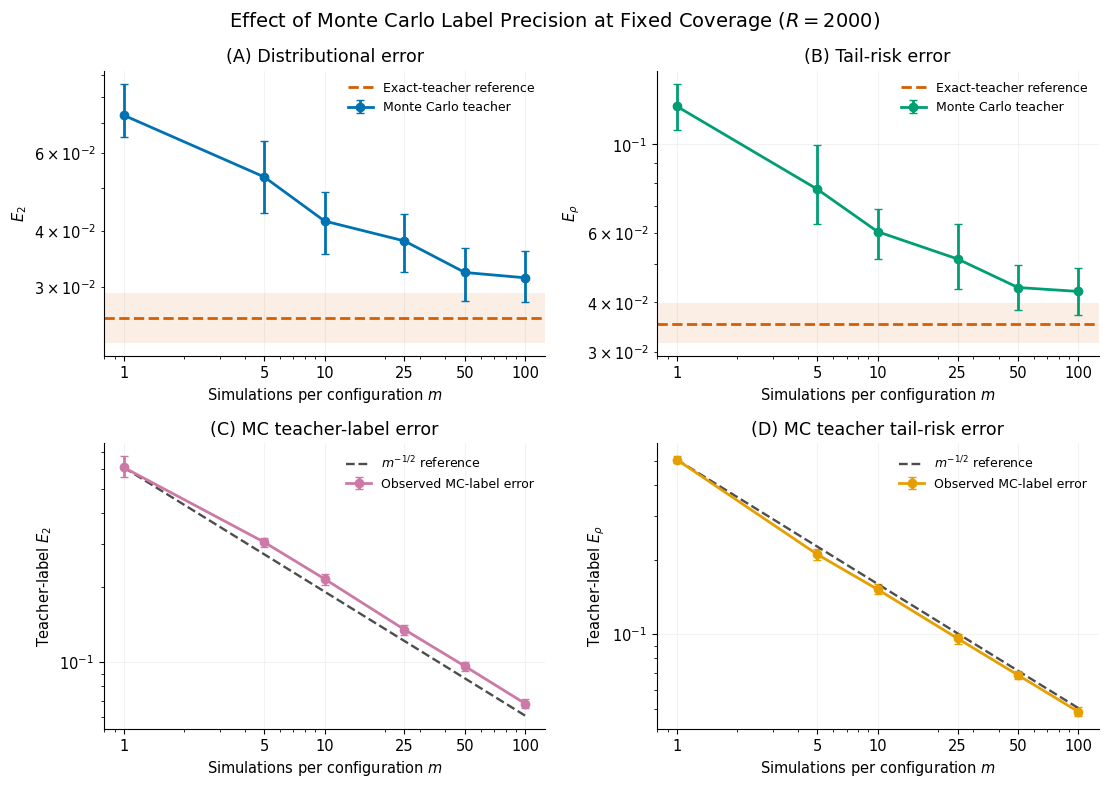


5.3-A m=50/m=100 EXTENSION COMPLETE
Final m grid: (1, 5, 10, 25, 50, 100)

Updated table:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/m50_m100_extension_v2/results/main_table_5_3A_m100.tex

Updated figure:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/m50_m100_extension_v2/results/figure_5_3A_m100.pdf

Precision contrasts:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/m50_m100_extension_v2/results/precision_increment_contrasts.csv

Exact-reference contrasts:
/content/drive/MyDrive/StatisticalLearning/Experiment_5_3A_JASA/run_20260823_084214/m50_m100_extension_v2/results/exact_reference_contrast_m100.csv


In [5]:
# =====================================================================================
# EXPERIMENT 5.3-A — SECOND CELL, CORRECTED EXTENSION
# ADD m = 50 AND m = 100
#
# IMPORTANT:
# We preserve the ORIGINAL m=25 empirical labels exactly and append:
#
#   +25 new independent paths  -> m=50
#   +50 additional paths       -> m=100
#
# Hence, by construction:
#
#       Y_25 ⊂ Y_50 ⊂ Y_100
#
# No attempt is made to reproduce the old Numba RNG stream bit-for-bit.
#
# RUN AFTER THE ORIGINAL 5.3-A CELL.
# =====================================================================================

import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from numba import njit, prange


# =====================================================================================
# 1. EXTENSION CONFIG
# =====================================================================================

M_NEW = (50,100)
M_ALL = (1,5,10,25,50,100)

# New folder prevents reuse of caches from the failed extension.
EXT_ROOT = ROOT/"m50_m100_extension_v2"
EXT_MC = EXT_ROOT/"mc"
EXT_MODELS = EXT_ROOT/"models"
EXT_CKPT = EXT_ROOT/"checkpoints"
EXT_OUT = EXT_ROOT/"results"

for d in (
    EXT_ROOT,
    EXT_MC,
    EXT_MODELS,
    EXT_CKPT,
    EXT_OUT
):
    d.mkdir(
        parents=True,
        exist_ok=True
    )


print("\n"+"="*100)
print("5.3-A CORRECTED EXTENSION: m = 50, 100")
print("="*100)

print("Original m:",M_VALUES)
print("Added m:",M_NEW)
print("Final grid:",M_ALL)
print("Extension root:",EXT_ROOT)


# =====================================================================================
# 2. GENERATE ONLY THE ADDITIONAL 75 PATHS
#
# For each configuration:
#
#   paths  1:25   = original m=25 teacher
#   paths 26:50   = new block A
#   paths 51:100  = new block B
#
# We use a path-specific deterministic seed. Therefore results are reproducible
# independently of Numba thread scheduling.
# =====================================================================================

@njit
def sim_C_with_seed(
    b,g,w,N,i0,seed
):
    np.random.seed(seed)

    S=N-i0
    I=i0
    R=0
    C=0

    while I>0:

        inf=b*S*I/N
        rec=g*I
        wan=w*R

        z=np.random.random()*(inf+rec+wan)

        if z<inf:

            S-=1
            I+=1
            C+=1

            if C>=N+1:
                return N+1

        elif z<inf+rec:

            I-=1
            R+=1

        else:

            R-=1
            S+=1

    return C


@njit(parallel=True)
def additional_mc_chunk(
    B,G,W,N,I0,
    global_start,
    maxN,
    rep_seed
):
    """
    Generate 75 NEW paths/configuration.

    First 25 additional paths:
        extend original 25 -> 50

    All 75 additional paths:
        extend original 25 -> 100
    """

    n=len(N)

    add25=np.zeros(
        (n,maxN+2),
        dtype=np.int16
    )

    add75=np.zeros(
        (n,maxN+2),
        dtype=np.int16
    )


    for j in prange(n):

        gj=global_start+j

        h25=np.zeros(
            maxN+2,
            dtype=np.int16
        )

        h75=np.zeros(
            maxN+2,
            dtype=np.int16
        )


        # -------------------------------------------------------------
        # q = 26,...,100
        #
        # Seed depends on:
        #   replication
        #   configuration
        #   trajectory index
        #
        # Therefore it is independent of thread scheduling.
        # -------------------------------------------------------------

        for q in range(26,101):

            path_seed=(
                rep_seed
                + 1000003*gj
                + 7919*q
            )

            c=sim_C_with_seed(
                B[j],G[j],W[j],
                N[j],I0[j],
                path_seed
            )

            h75[c]+=1

            if q<=50:
                h25[c]+=1


        add25[j,:]=h25
        add75[j,:]=h75


    return add25,add75


# =====================================================================================
# 3. EXACTLY RECOVER ORIGINAL m=25 COUNTS
# =====================================================================================

def labels_to_counts(
    labels,
    m
):
    """
    Convert stored empirical probabilities back to integer counts.

    Because the original labels equal counts/m, rounding recovers the counts.
    """

    out=[]

    for j,p in enumerate(labels):

        p=np.asarray(
            p,
            dtype=np.float64
        )

        counts=np.rint(
            m*p
        ).astype(
            np.int64
        )

        if counts.sum()!=m:

            raise RuntimeError(
                f"Configuration {j}: "
                f"recovered count total={counts.sum()}, expected {m}."
            )

        if np.any(counts<0):

            raise RuntimeError(
                f"Configuration {j}: negative recovered count."
            )

        out.append(counts)

    return out


# =====================================================================================
# 4. CONSTRUCT NESTED m=50 AND m=100 LABELS
# =====================================================================================

def extended_mc_labels(rep):

    folder=EXT_MC/f"rep_{rep:02d}"

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


    final=folder/"labels_m50_m100.pkl"


    if final.exists():

        z=load_pickle(final)

        if (
            z is not None
            and
            50 in z
            and
            100 in z
            and
            len(z[50])==cfg.R
            and
            len(z[100])==cfg.R
        ):

            print(
                f"MC extension rep {rep}: final cache"
            )

            return z


    # -------------------------------------------------------------------------
    # ORIGINAL m=25 labels
    # -------------------------------------------------------------------------

    original=mc_labels(rep)

    old25=original[25]

    counts25=labels_to_counts(
        old25,
        25
    )


    # -------------------------------------------------------------------------
    # Configuration arrays
    # -------------------------------------------------------------------------

    B=np.asarray(
        [r.b for r in train],
        dtype=np.float64
    )

    G=np.asarray(
        [r.g for r in train],
        dtype=np.float64
    )

    W=np.asarray(
        [r.w for r in train],
        dtype=np.float64
    )

    N=np.asarray(
        [r.N for r in train],
        dtype=np.int64
    )

    I0=np.asarray(
        [r.i0 for r in train],
        dtype=np.int64
    )


    # Separate extension seed.
    rep_seed=(
        cfg.seed
        + 30000000
        + rep*2000003
    )


    # Compile
    _=additional_mc_chunk(
        np.asarray([.8]),
        np.asarray([.5]),
        np.asarray([.1]),
        np.asarray([40],dtype=np.int64),
        np.asarray([1],dtype=np.int64),
        0,
        40,
        rep_seed
    )


    add25_all=[]
    add75_all=[]


    # -------------------------------------------------------------------------
    # Resumable chunks
    # -------------------------------------------------------------------------

    for start in range(
        0,
        cfg.R,
        MC_CHUNK
    ):

        end=min(
            start+MC_CHUNK,
            cfg.R
        )


        f=folder/f"chunk_{start:05d}_{end:05d}.pkl"

        part=(
            load_pickle(f)
            if f.exists()
            else None
        )


        valid=(
            isinstance(part,dict)
            and
            "add25" in part
            and
            "add75" in part
            and
            part["add25"].shape==(
                end-start,
                N_SCALE+2
            )
            and
            part["add75"].shape==(
                end-start,
                N_SCALE+2
            )
        )


        if not valid:

            t0=time.perf_counter()


            a25,a75=additional_mc_chunk(
                B[start:end],
                G[start:end],
                W[start:end],
                N[start:end],
                I0[start:end],
                start,
                N_SCALE,
                rep_seed
            )


            part={
                "add25":a25,
                "add75":a75
            }


            atomic_pickle(
                part,
                f
            )


            print(
                f"MC ext rep={rep} "
                f"{start:4d}:{end:4d} | "
                f"{time.perf_counter()-t0:.1f}s | saved"
            )


        else:

            print(
                f"MC ext rep={rep} "
                f"{start:4d}:{end:4d} | cache"
            )


        add25_all.append(
            part["add25"]
        )

        add75_all.append(
            part["add75"]
        )


    add25_all=np.concatenate(
        add25_all,
        axis=0
    )

    add75_all=np.concatenate(
        add75_all,
        axis=0
    )


    # -------------------------------------------------------------------------
    # Construct nested empirical distributions
    # -------------------------------------------------------------------------

    labels50=[]
    labels100=[]


    for j,r in enumerate(train):

        K=r.N+2

        old=np.asarray(
            counts25[j],
            dtype=np.int64
        )


        a25=add25_all[
            j,
            :K
        ].astype(
            np.int64
        )


        a75=add75_all[
            j,
            :K
        ].astype(
            np.int64
        )


        # Important:
        # a75 includes a25 because it summarizes all added paths 26:100.
        counts50=old+a25
        counts100=old+a75


        if counts50.sum()!=50:

            raise RuntimeError(
                f"rep={rep}, config={j}: "
                f"m50 total={counts50.sum()}."
            )


        if counts100.sum()!=100:

            raise RuntimeError(
                f"rep={rep}, config={j}: "
                f"m100 total={counts100.sum()}."
            )


        labels50.append(
            (
                counts50/50.
            ).astype(
                np.float32
            )
        )


        labels100.append(
            (
                counts100/100.
            ).astype(
                np.float32
            )
        )


    result={
        50:labels50,
        100:labels100
    }


    atomic_pickle(
        result,
        final
    )


    print(
        f"rep {rep}: "
        "nested m25 -> m50 -> m100 labels constructed successfully."
    )


    return result


# =====================================================================================
# 5. RESUMABLE TRAINING FOR m=50 AND m=100
# =====================================================================================

def fit_extension(
    TR,
    VA,
    rep,
    m,
    seed
):

    name=f"rep{rep:02d}_MC_R2000_m{m}"


    final=(
        EXT_MODELS
        /
        f"{name}_FINAL.pt"
    )


    checkpoint=(
        EXT_CKPT
        /
        f"{name}_CHECKPOINT.pt"
    )


    if final.exists():

        z=torch.load(
            final,
            map_location="cpu",
            weights_only=False
        )

        net=HazardNet()

        net.load_state_dict(
            z["state"]
        )

        print(
            f"{name}: FINAL | "
            f"best epoch={z['best_epoch']}"
        )

        return net,z


    # SAME initialization used by all teachers in this replication
    seed_all(seed)

    net=HazardNet()


    opt=torch.optim.AdamW(
        net.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.wd
    )


    sch=torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=.5,
        patience=15
    )


    # SAME batch randomization
    rng=np.random.default_rng(
        seed+8
    )


    start_epoch=1
    best=np.inf
    best_epoch=0
    best_state=None
    wait=0
    history=[]
    previous_elapsed=0.


    if checkpoint.exists():

        z=torch.load(
            checkpoint,
            map_location="cpu",
            weights_only=False
        )


        net.load_state_dict(
            z["model"]
        )

        opt.load_state_dict(
            z["optimizer"]
        )

        sch.load_state_dict(
            z["scheduler"]
        )


        start_epoch=z["epoch"]+1

        best=z["best"]
        best_epoch=z["best_epoch"]
        best_state=z["best_state"]
        wait=z["wait"]
        history=z["history"]
        previous_elapsed=z["elapsed"]


        rng.bit_generator.state=z[
            "rng_state"
        ]

        torch.set_rng_state(
            z["torch_rng"]
        )


        print(
            f"{name}: resume epoch {start_epoch}"
        )


    start=time.perf_counter()
    stopped=cfg.epochs


    for epoch in range(
        start_epoch,
        cfg.epochs+1
    ):

        net.train()


        for NN,idx in batches(
            TR,
            rng,
            True
        ):

            X=TR[NN]["X"][idx]
            Y=TR[NN]["Y"][idx]


            opt.zero_grad(
                set_to_none=True
            )


            L=loss_batch(
                net,
                X,
                Y
            )


            if not torch.isfinite(L):

                raise RuntimeError(
                    f"{name}: non-finite loss."
                )


            L.backward()


            torch.nn.utils.clip_grad_norm_(
                net.parameters(),
                cfg.clip
            )


            opt.step()


        v=val_loss(
            net,
            VA
        )


        sch.step(v)

        history.append(
            float(v)
        )


        if (
            best_state is None
            or
            v<best-cfg.min_delta
        ):

            best=float(v)
            best_epoch=epoch

            best_state=cpu_state(
                net.state_dict()
            )

            wait=0


        else:

            wait+=1


        if (
            epoch==1
            or
            epoch%CHECKPOINT_EVERY==0
        ):

            elapsed=(
                previous_elapsed
                +
                time.perf_counter()
                -
                start
            )


            atomic_torch(
                {
                    "epoch":epoch,
                    "model":
                        cpu_state(
                            net.state_dict()
                        ),
                    "optimizer":
                        opt.state_dict(),
                    "scheduler":
                        sch.state_dict(),
                    "best":
                        best,
                    "best_epoch":
                        best_epoch,
                    "best_state":
                        best_state,
                    "wait":
                        wait,
                    "history":
                        history,
                    "rng_state":
                        rng.bit_generator.state,
                    "torch_rng":
                        torch.get_rng_state(),
                    "elapsed":
                        elapsed
                },
                checkpoint
            )


            print(
                f"{name} | "
                f"ep={epoch:3d} | "
                f"val={v:.4e} | "
                f"best={best:.4e} | "
                f"wait={wait}"
            )


        if wait>=cfg.patience:

            stopped=epoch
            break


    elapsed=(
        previous_elapsed
        +
        time.perf_counter()
        -
        start
    )


    if best_state is None:

        raise RuntimeError(
            f"{name}: no valid model."
        )


    net.load_state_dict(
        best_state
    )


    payload={
        "state":best_state,
        "best_epoch":best_epoch,
        "stopped_epoch":stopped,
        "validation":best,
        "training_sec":elapsed,
        "history":history
    }


    atomic_torch(
        payload,
        final
    )


    if checkpoint.exists():

        checkpoint.unlink()


    print(
        f"{name}: COMPLETE | "
        f"best={best_epoch} | "
        f"stop={stopped}"
    )


    return net,payload


# =====================================================================================
# 6. RUN FIVE REPLICATIONS
# =====================================================================================

EXT_PROGRESS_FILE=(
    EXT_ROOT
    /
    "extension_progress.pkl"
)


ext_progress=load_pickle(
    EXT_PROGRESS_FILE,
    {
        "mc":{},
        "label":{}
    }
)


for key in (
    "mc",
    "label"
):

    ext_progress.setdefault(
        key,
        {}
    )


for rep in range(
    1,
    N_REP+1
):

    print("\n"+"="*100)

    print(
        f"EXTENSION REPLICATION "
        f"{rep}/{N_REP}"
    )

    print("="*100)


    train_seed=(
        cfg.seed
        +7001
        +rep*100003
    )


    labels_ext=extended_mc_labels(
        rep
    )


    for m in M_NEW:

        key=f"rep{rep:02d}_m{m}"


        # ---------------------------------------------------------------------
        # Teacher-label errors
        # ---------------------------------------------------------------------

        if key not in ext_progress["label"]:

            ext_progress["label"][key]=teacher_errors(
                train,
                labels_ext[m]
            )


            atomic_pickle(
                ext_progress,
                EXT_PROGRESS_FILE
            )


        # ---------------------------------------------------------------------
        # Neural fit
        # ---------------------------------------------------------------------

        if key in ext_progress["mc"]:

            print(
                f"{key}: complete — skipping"
            )

            continue


        TR=pack(
            train,
            labels_ext[m]
        )


        net,meta=fit_extension(
            TR,
            VA,
            rep,
            m,
            train_seed
        )


        z=evaluate(
            net,
            TE,
            len(test)
        )


        ext_progress["mc"][key]={
            "m":m,
            **z,
            "training_sec":
                meta["training_sec"],
            "best_epoch":
                meta["best_epoch"],
            "stopped_epoch":
                meta["stopped_epoch"]
        }


        atomic_pickle(
            ext_progress,
            EXT_PROGRESS_FILE
        )


        print(
            f"m={m:3d} | "
            f"E2={np.median(z['E2']):.5g} | "
            f"Erho={np.median(z['Erho']):.5g}"
        )


        del TR,net


# =====================================================================================
# 7. NEW RESULT MATRICES
# =====================================================================================

def ext_mc_matrix(
    m,
    metric
):

    return np.vstack([

        ext_progress["mc"][
            f"rep{rep:02d}_m{m}"
        ][metric]

        for rep in range(
            1,
            N_REP+1
        )

    ])


def ext_label_matrix(
    m,
    metric
):

    return np.vstack([

        ext_progress["label"][
            f"rep{rep:02d}_m{m}"
        ][metric]

        for rep in range(
            1,
            N_REP+1
        )

    ])


# =====================================================================================
# 8. SUMMARIZE m=50 AND m=100
# =====================================================================================

new_rows=[]


for k,m in enumerate(
    M_NEW
):

    e2=summarize(
        ext_mc_matrix(m,"E2"),
        cfg.seed+11000+k
    )

    er=summarize(
        ext_mc_matrix(m,"Erho"),
        cfg.seed+12000+k
    )

    kl=summarize(
        ext_mc_matrix(m,"KL"),
        cfg.seed+13000+k
    )

    le2=summarize(
        ext_label_matrix(m,"E2"),
        cfg.seed+14000+k
    )

    ler=summarize(
        ext_label_matrix(m,"Erho"),
        cfg.seed+15000+k
    )


    new_rows.append({

        "Teacher":"Monte Carlo",
        "m":m,

        "E2_med":e2["median"],
        "E2_q1":e2["q1"],
        "E2_q3":e2["q3"],
        "E2_p95":e2["p95"],
        "E2_CI_low":e2["CI_low"],
        "E2_CI_high":e2["CI_high"],

        "Erho_med":er["median"],
        "Erho_q1":er["q1"],
        "Erho_q3":er["q3"],
        "Erho_p95":er["p95"],
        "Erho_CI_low":er["CI_low"],
        "Erho_CI_high":er["CI_high"],

        "KL_med":kl["median"],

        "label_E2_med":
            le2["median"],
        "label_E2_CI_low":
            le2["CI_low"],
        "label_E2_CI_high":
            le2["CI_high"],

        "label_Erho_med":
            ler["median"],
        "label_Erho_CI_low":
            ler["CI_low"],
        "label_Erho_CI_high":
            ler["CI_high"]

    })


new_summary=pd.DataFrame(
    new_rows
)


# =====================================================================================
# 9. MERGE WITH ORIGINAL RESULTS
# =====================================================================================

summary_extended=pd.concat(
    [
        summary.copy(),
        new_summary
    ],
    ignore_index=True
)


summary_extended["_order"]=np.where(
    summary_extended.Teacher=="Exact reference",
    -1,
    summary_extended.m
)


summary_extended=(
    summary_extended
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)


summary_extended.to_csv(
    EXT_OUT/"full_numeric_summary_m100.csv",
    index=False
)


# =====================================================================================
# 10. UPDATED MAIN TABLE
# =====================================================================================

def fmt_ext(
    med,
    lo,
    hi
):

    return (
        f"{med:.4g} "
        f"[{lo:.4g}, {hi:.4g}]"
    )


table_rows=[]


for _,z in summary_extended.iterrows():

    table_rows.append({

        "Teacher":
            z["Teacher"],

        "m":
            (
                "--"
                if pd.isna(z["m"])
                else str(int(z["m"]))
            ),

        "E2 median [95% CI]":
            fmt_ext(
                z["E2_med"],
                z["E2_CI_low"],
                z["E2_CI_high"]
            ),

        "E2 p95":
            f"{z['E2_p95']:.4g}",

        "Erho median [95% CI]":
            fmt_ext(
                z["Erho_med"],
                z["Erho_CI_low"],
                z["Erho_CI_high"]
            ),

        "Erho p95":
            f"{z['Erho_p95']:.4g}",

        "MC-label E2":
            f"{z['label_E2_med']:.4g}",

        "MC-label Erho":
            f"{z['label_Erho_med']:.4g}"

    })


table_extended=pd.DataFrame(
    table_rows
)


table_extended.to_csv(
    EXT_OUT/"main_table_5_3A_m100.csv",
    index=False
)


(
    EXT_OUT/"main_table_5_3A_m100.tex"
).write_text(
    table_extended.to_latex(
        index=False,
        escape=False
    )
)


print("\n"+"="*120)
print("EXTENDED MAIN TABLE")
print("="*120)

print(
    table_extended.to_string(
        index=False
    )
)


# =====================================================================================
# 11. MC-vs-EXACT CONTRASTS FOR m=50,100
# =====================================================================================

new_exact_contrast=[]


for k,m in enumerate(
    M_NEW
):

    for j,metric in enumerate(
        ("E2","Erho")
    ):

        z=paired_contrast(
            ext_mc_matrix(
                m,
                metric
            ),
            exact_matrix(
                metric
            ),
            cfg.seed+16000+100*k+j
        )


        new_exact_contrast.append({
            "m":m,
            "metric":metric,
            "contrast":"MC minus exact",
            **z
        })


new_exact_contrast=pd.DataFrame(
    new_exact_contrast
)


contrast_extended=pd.concat(
    [
        contrast.copy(),
        new_exact_contrast
    ],
    ignore_index=True
)


contrast_extended.to_csv(
    EXT_OUT/"exact_reference_contrast_m100.csv",
    index=False
)


# =====================================================================================
# 12. PRECISION-INCREMENT CONTRASTS
#
# Negative = improvement with higher m.
# =====================================================================================

def matrix_for_m(
    m,
    metric
):

    if m in (
        1,5,10,25
    ):

        return mc_matrix(
            m,
            metric
        )

    return ext_mc_matrix(
        m,
        metric
    )


precision_rows=[]


for m_hi,m_lo in (
    (50,25),
    (100,50),
    (100,25)
):

    for j,metric in enumerate(
        ("E2","Erho")
    ):

        z=paired_contrast(
            matrix_for_m(
                m_hi,
                metric
            ),
            matrix_for_m(
                m_lo,
                metric
            ),
            cfg.seed
            +17000
            +100*m_hi
            +10*m_lo
            +j
        )


        precision_rows.append({

            "higher_m":
                m_hi,

            "lower_m":
                m_lo,

            "metric":
                metric,

            "contrast":
                f"m{m_hi} minus m{m_lo}",

            **z

        })


precision_contrast=pd.DataFrame(
    precision_rows
)


precision_contrast.to_csv(
    EXT_OUT/"precision_increment_contrasts.csv",
    index=False
)


print("\n"+"="*105)
print("PRECISION-INCREMENT CONTRASTS")
print("Negative = improvement at higher m")
print("="*105)

print(
    precision_contrast.to_string(
        index=False
    )
)


# =====================================================================================
# 13. UPDATED MAIN FIGURE
#
# Bottom panels additionally show m^{-1/2} reference.
# =====================================================================================

mc_ext=(
    summary_extended[
        summary_extended.Teacher=="Monte Carlo"
    ]
    .copy()
    .sort_values("m")
)


x=mc_ext.m.to_numpy(
    dtype=float
)


exact_ext=summary_extended[
    summary_extended.Teacher=="Exact reference"
].iloc[0]


plt.rcParams.update({
    "font.size":10.5,
    "axes.spines.top":False,
    "axes.spines.right":False
})


fig,ax=plt.subplots(
    2,
    2,
    figsize=(11.2,8.0)
)


# -------------------------------------------------------------------------
# A-B: emulator errors
# -------------------------------------------------------------------------

for a,prefix,title,color in (

    (
        ax[0,0],
        "E2",
        "(A) Distributional error",
        "#0072B2"
    ),

    (
        ax[0,1],
        "Erho",
        "(B) Tail-risk error",
        "#009E73"
    )

):

    med=mc_ext[
        f"{prefix}_med"
    ].to_numpy()

    lo=mc_ext[
        f"{prefix}_CI_low"
    ].to_numpy()

    hi=mc_ext[
        f"{prefix}_CI_high"
    ].to_numpy()


    a.errorbar(
        x,
        med,
        yerr=np.vstack([
            med-lo,
            hi-med
        ]),
        fmt="o-",
        color=color,
        lw=2,
        capsize=3,
        label="Monte Carlo teacher"
    )


    exact_med=exact_ext[
        f"{prefix}_med"
    ]

    exact_lo=exact_ext[
        f"{prefix}_CI_low"
    ]

    exact_hi=exact_ext[
        f"{prefix}_CI_high"
    ]


    a.axhline(
        exact_med,
        color="#D55E00",
        ls="--",
        lw=2,
        label="Exact-teacher reference"
    )


    a.axhspan(
        exact_lo,
        exact_hi,
        color="#D55E00",
        alpha=.10,
        linewidth=0
    )


    a.set_title(
        title
    )

    a.set_ylabel(
        r"$E_2$"
        if prefix=="E2"
        else r"$E_\rho$"
    )


# -------------------------------------------------------------------------
# C-D: label errors + m^{-1/2}
# -------------------------------------------------------------------------

for a,prefix,title,color in (

    (
        ax[1,0],
        "label_E2",
        "(C) MC teacher-label error",
        "#CC79A7"
    ),

    (
        ax[1,1],
        "label_Erho",
        "(D) MC teacher tail-risk error",
        "#E69F00"
    )

):

    med=mc_ext[
        f"{prefix}_med"
    ].to_numpy()

    lo=mc_ext[
        f"{prefix}_CI_low"
    ].to_numpy()

    hi=mc_ext[
        f"{prefix}_CI_high"
    ].to_numpy()


    a.errorbar(
        x,
        med,
        yerr=np.vstack([
            med-lo,
            hi-med
        ]),
        fmt="o-",
        color=color,
        lw=2,
        capsize=3,
        label="Observed MC-label error"
    )


    # reference normalized at m=1
    ref=(
        med[0]
        *
        np.sqrt(
            x[0]/x
        )
    )


    a.plot(
        x,
        ref,
        "--",
        color=".30",
        lw=1.7,
        label=r"$m^{-1/2}$ reference"
    )


    a.set_title(
        title
    )

    a.set_ylabel(
        r"Teacher-label $E_2$"
        if prefix=="label_E2"
        else r"Teacher-label $E_\rho$"
    )


for a in ax.flat:

    a.set_xscale(
        "log"
    )

    a.set_yscale(
        "log"
    )

    a.set_xticks(
        M_ALL
    )

    a.set_xticklabels(
        M_ALL
    )

    a.set_xlabel(
        r"Simulations per configuration $m$"
    )

    a.grid(
        alpha=.15
    )


for a in (
    ax[0,0],
    ax[0,1],
    ax[1,0],
    ax[1,1]
):

    a.legend(
        frameon=False,
        fontsize=9
    )


fig.suptitle(
    r"Effect of Monte Carlo Label Precision at Fixed Coverage ($R=2000$)",
    fontsize=14
)


plt.tight_layout()


plt.savefig(
    EXT_OUT/"figure_5_3A_m100.pdf",
    bbox_inches="tight"
)


plt.savefig(
    EXT_OUT/"figure_5_3A_m100.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================================
# 14. SAVE EXTENSION
# =====================================================================================

atomic_pickle(
    {
        "M_VALUES":
            M_ALL,

        "summary":
            summary_extended,

        "main_table":
            table_extended,

        "exact_reference_contrast":
            contrast_extended,

        "precision_increment_contrasts":
            precision_contrast,

        "nesting":
            (
                "Original m=25 empirical counts preserved exactly; "
                "25 new paths appended for m=50 and 50 further paths "
                "appended for m=100."
            )
    },
    EXT_OUT/"section_5_3A_m100_extension.pkl"
)


print("\n"+"="*105)
print("5.3-A m=50/m=100 EXTENSION COMPLETE")
print("="*105)

print("Final m grid:",M_ALL)

print("\nUpdated table:")
print(
    EXT_OUT/"main_table_5_3A_m100.tex"
)

print("\nUpdated figure:")
print(
    EXT_OUT/"figure_5_3A_m100.pdf"
)

print("\nPrecision contrasts:")
print(
    EXT_OUT/"precision_increment_contrasts.csv"
)

print("\nExact-reference contrasts:")
print(
    EXT_OUT/"exact_reference_contrast_m100.csv"
)

print("="*105)